In [1]:
import requests, pandas as pd
from requests.auth import HTTPBasicAuth
from dotenv import load_dotenv
import os

load_dotenv()  # Load from .env

reed_key = os.getenv("REED_API_KEY")

base = "https://www.reed.co.uk/api/1.0/search"
all_jobs = []

for skip in range(0, 1000, 100):  # Pages of 100 up to 1000
    params = {
        "keywords": "data analyst",
        "locationName": "United Kingdom",
        "resultsToTake": 100,
        "resultsToSkip": skip
    }
    resp = requests.get(base, auth=HTTPBasicAuth(reed_key, ""), params=params)
    data = resp.json().get('results', [])
    all_jobs.extend(data)

jobs_reed = pd.json_normalize(all_jobs)
jobs_reed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   jobId                1000 non-null   int64  
 1   employerId           1000 non-null   int64  
 2   employerName         1000 non-null   object 
 3   employerProfileId    0 non-null      object 
 4   employerProfileName  0 non-null      object 
 5   jobTitle             1000 non-null   object 
 6   locationName         1000 non-null   object 
 7   minimumSalary        839 non-null    float64
 8   maximumSalary        839 non-null    float64
 9   currency             839 non-null    object 
 10  expirationDate       1000 non-null   object 
 11  date                 1000 non-null   object 
 12  jobDescription       1000 non-null   object 
 13  applications         1000 non-null   int64  
 14  jobUrl               1000 non-null   object 
dtypes: float64(2), int64(3), object(10)
mem

In [2]:
# Save to CSV
jobs_reed.to_csv('data_analyst_jobs.csv', index=False)
print("Data saved to 'data_analyst_jobs.csv'")


Data saved to 'data_analyst_jobs.csv'


In [3]:
jobs_reed.isnull().sum()

jobId                     0
employerId                0
employerName              0
employerProfileId      1000
employerProfileName    1000
jobTitle                  0
locationName              0
minimumSalary           161
maximumSalary           161
currency                161
expirationDate            0
date                      0
jobDescription            0
applications              0
jobUrl                    0
dtype: int64

In [4]:
            # Dropping column which is completely missing like employerProfileId and employerProfileName
jobs_reed.drop(columns=["employerProfileId", "employerProfileName"], inplace=True)
# Filter rows with posting date from March 2025 onwards
jobs_reed['date'] = pd.to_datetime(jobs_reed['date'], format='%d/%m/%Y', errors='coerce')
jobs_reed = jobs_reed[jobs_reed['date'] >= '2025-03-01']

jobs_reed.head()


,jobId,employerId,employerName,jobTitle,locationName,minimumSalary,maximumSalary,currency,expirationDate,date,jobDescription,applications,jobUrl
0,55498827,675821,AJR Management Ltd,Data Analyst,DE130AT,27070.0,27070.0,GBP,09/09/2025,2025-07-29,Join a growing team in a dynamic environment! ...,163,https://www.reed.co.uk/jobs/data-analyst/55498827
1,55472028,422355,McCormick UK Limited,Data Analyst,Peterborough,NaN,NaN,None,04/09/2025,2025-07-24,"Data Analyst Peterborough, UK This role suppor...",88,https://www.reed.co.uk/jobs/data-analyst/55472028
2,54606079,510736,Sagacity,Data Analyst,EC1N2TD,NaN,NaN,None,12/09/2025,2025-03-07,Principal responsibilities will involve: Turn ...,3557,https://www.reed.co.uk/jobs/data-analyst/54606079
3,55545639,401475,Mortgage Advice Bureau (MAB),Data Analyst,DE248QR,NaN,NaN,None,16/09/2025,2025-08-05,"Permanent, Full-time (37.5 hours, Monday to Fr...",43,https://www.reed.co.uk/jobs/data-analyst/55545639
4,55420266,500373,QA,AI & Data Analyst Apprentice,B24QA,16000.0,16000.0,GBP,26/08/2025,2025-07-15,"In today’s data-driven world, roles in data an...",83,https://www.reed.co.uk/jobs/ai-data-analyst-ap...


In [5]:
                # Filling missing values on minimumSalary,minimumSalary and currency

In [6]:
# Drop NaNs to avoid errors in calculations
min_salary = jobs_reed['minimumSalary']
max_salary = jobs_reed['maximumSalary']

# Fill missing values in 'minimumSalary' and 'maximumSalary' with the median salary
jobs_reed['minimumSalary'] = jobs_reed['minimumSalary'].fillna(jobs_reed['minimumSalary'].median())
jobs_reed['maximumSalary'] = jobs_reed['maximumSalary'].fillna(jobs_reed['maximumSalary'].median())


# Get the most frequent currency value
currency_mode = jobs_reed['currency'].mode().iloc[0]
# print(f"Most frequent currency: {currency_mode}")

# Fill missing values in 'currency' with the mode to maintain consistency in currency data
jobs_reed['currency'] = jobs_reed['currency'].fillna(currency_mode)

In [7]:
# Drop rows where both minimumSalary and maximumSalary are 0
jobs_reed = jobs_reed[~((jobs_reed['minimumSalary'] == 0) & (jobs_reed['maximumSalary'] == 0))]

# Drop rows where both minimumSalary or maximumSalary >150000
jobs_reed = jobs_reed[~((jobs_reed['minimumSalary'] > 150000)  | (jobs_reed['maximumSalary'] > 150000))]

# Drop rows where applications > 600
jobs_reed = jobs_reed[~((jobs_reed['applications'] > 600))]



# Checking
jobs_reed[(jobs_reed['minimumSalary'] == 0) | (jobs_reed['maximumSalary'] == 0)]

jobs_reed[(jobs_reed['minimumSalary'] > 150000) | (jobs_reed['maximumSalary'] > 150000)]

jobs_reed[(jobs_reed['applications'] > 600)]


,jobId,employerId,employerName,jobTitle,locationName,minimumSalary,maximumSalary,currency,expirationDate,date,jobDescription,applications,jobUrl


In [8]:
jobs_reed.describe()


,jobId,employerId,minimumSalary,maximumSalary,date,applications
count,9.770000e+02,977.000000,977.000000,977.000000,977,977.000000
mean,5.544663e+07,479894.294780,35137.664207,45973.128465,2025-07-19 22:49:15.168884480,49.436029
min,5.460720e+07,2763.000000,12.600000,12.600000,2025-03-07 00:00:00,0.000000
25%,5.541076e+07,385714.000000,30000.000000,40000.000000,2025-07-14 00:00:00,7.000000
50%,5.546468e+07,524744.000000,33593.000000,50000.000000,2025-07-23 00:00:00,28.000000
75%,5.550884e+07,582327.000000,45000.000000,50000.000000,2025-07-30 00:00:00,65.000000
max,5.555786e+07,690217.000000,100000.000000,130000.000000,2025-08-07 00:00:00,570.000000
std,1.019606e+05,153351.040759,16160.288975,19492.534426,NaN,65.205808


In [9]:
jobs_reed.info()


<class 'pandas.core.frame.DataFrame'>
Index: 977 entries, 0 to 999
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   jobId           977 non-null    int64         
 1   employerId      977 non-null    int64         
 2   employerName    977 non-null    object        
 3   jobTitle        977 non-null    object        
 4   locationName    977 non-null    object        
 5   minimumSalary   977 non-null    float64       
 6   maximumSalary   977 non-null    float64       
 7   currency        977 non-null    object        
 8   expirationDate  977 non-null    object        
 9   date            977 non-null    datetime64[ns]
 10  jobDescription  977 non-null    object        
 11  applications    977 non-null    int64         
 12  jobUrl          977 non-null    object        
dtypes: datetime64[ns](1), float64(2), int64(3), object(7)
memory usage: 106.9+ KB


In [10]:
# Convert 'date' column to datetime 
jobs_reed['date'] = pd.to_datetime(jobs_reed['date'], dayfirst=True)
jobs_reed['expirationDate'] = pd.to_datetime(jobs_reed['expirationDate'], dayfirst=True)


In [11]:
jobs_reed['date'] = pd.to_datetime(jobs_reed['date'])

# Calculate how many days old the job posting is
jobs_reed['jobAgeDays'] = (pd.Timestamp.today() - jobs_reed['date']).dt.days
jobs_reed

,jobId,employerId,employerName,jobTitle,locationName,minimumSalary,maximumSalary,currency,expirationDate,date,jobDescription,applications,jobUrl,jobAgeDays
0,55498827,675821,AJR Management Ltd,Data Analyst,DE130AT,27070.0,27070.0,GBP,2025-09-09,2025-07-29,Join a growing team in a dynamic environment! ...,163,https://www.reed.co.uk/jobs/data-analyst/55498827,9
1,55472028,422355,McCormick UK Limited,Data Analyst,Peterborough,33593.0,50000.0,GBP,2025-09-04,2025-07-24,"Data Analyst Peterborough, UK This role suppor...",88,https://www.reed.co.uk/jobs/data-analyst/55472028,14
3,55545639,401475,Mortgage Advice Bureau (MAB),Data Analyst,DE248QR,33593.0,50000.0,GBP,2025-09-16,2025-08-05,"Permanent, Full-time (37.5 hours, Monday to Fr...",43,https://www.reed.co.uk/jobs/data-analyst/55545639,2
4,55420266,500373,QA,AI & Data Analyst Apprentice,B24QA,16000.0,16000.0,GBP,2025-08-26,2025-07-15,"In today’s data-driven world, roles in data an...",83,https://www.reed.co.uk/jobs/ai-data-analyst-ap...,23
5,55420167,500373,QA,AI & Data Analyst Apprentice,NE15DL,16000.0,16000.0,GBP,2025-08-26,2025-07-15,"In today’s data-driven world, roles in data an...",17,https://www.reed.co.uk/jobs/ai-data-analyst-ap...,23
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,55322189,392757,Elevation Recruitment Group,Commercial Finance Analyst,Alfreton,28000.0,33000.0,GBP,2025-08-11,2025-06-30,"Commercial Finance Analyst&nbsp; Alfreton, Der...",20,https://www.reed.co.uk/jobs/commercial-finance...,38
996,55419499,598612,Michael Page Technology,Business Intelligence Analyst / Developer,Walsall,40000.0,45000.0,GBP,2025-08-12,2025-07-15,This leading Property Organisation require a B...,97,https://www.reed.co.uk/jobs/business-intellige...,23
997,55552148,377106,Robert Walters,Senior Financial Analyst,London,100000.0,130000.0,GBP,2025-09-17,2025-08-06,We are working with a high growth renewables b...,19,https://www.reed.co.uk/jobs/senior-financial-a...,1
998,55439542,404159,Investigo,Commercial Finance Analyst,London,38000.0,45000.0,GBP,2025-08-29,2025-07-18,Commercial Finance Analyst - Retail up to 45k ...,96,https://www.reed.co.uk/jobs/commercial-finance...,20


In [12]:

# Statistics for minimumSalary
print("Minimum Salary Stats:")
print(f"Min: {min_salary.min()}")
print(f"Max: {min_salary.max()}") 
print(f"Mean: {min_salary.mean()}")
print(f"Mode: {min_salary.mode().values}")
print(f"Standard Deviation: {min_salary.std()}")
print()

# Statistics for maximumSalary
print("Maximum Salary Stats:")
print(f"Min: {max_salary.min()}")
print(f"Max: {max_salary.max()}")
print(f"Mean: {max_salary.mean()}")
print(f"Mode: {max_salary.mode().values}")
print(f"Standard Deviation: {max_salary.std()}")

Minimum Salary Stats:
Min: 0.0
Max: 100000.0
Mean: 35158.9914716526
Mode: [30000.]
Standard Deviation: 17920.146157207382

Maximum Salary Stats:
Min: 0.0
Max: 670000.0
Mean: 46243.3612907117
Mode: [50000.]
Standard Deviation: 37095.377346529014


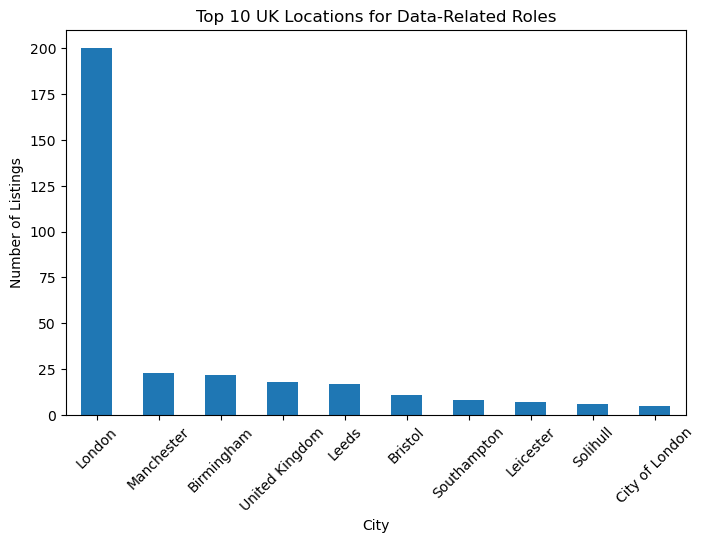

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
top_locations = jobs_reed['locationName'].value_counts().head(10)
top_titles    = jobs_reed['jobTitle'].value_counts().head(10)

plt.figure(figsize=(8,5))
top_locations.plot(kind='bar')
plt.title('Top 10 UK Locations for Data-Related Roles')
plt.xlabel('City')
plt.ylabel('Number of Listings')
plt.xticks(rotation=45)
plt.show()


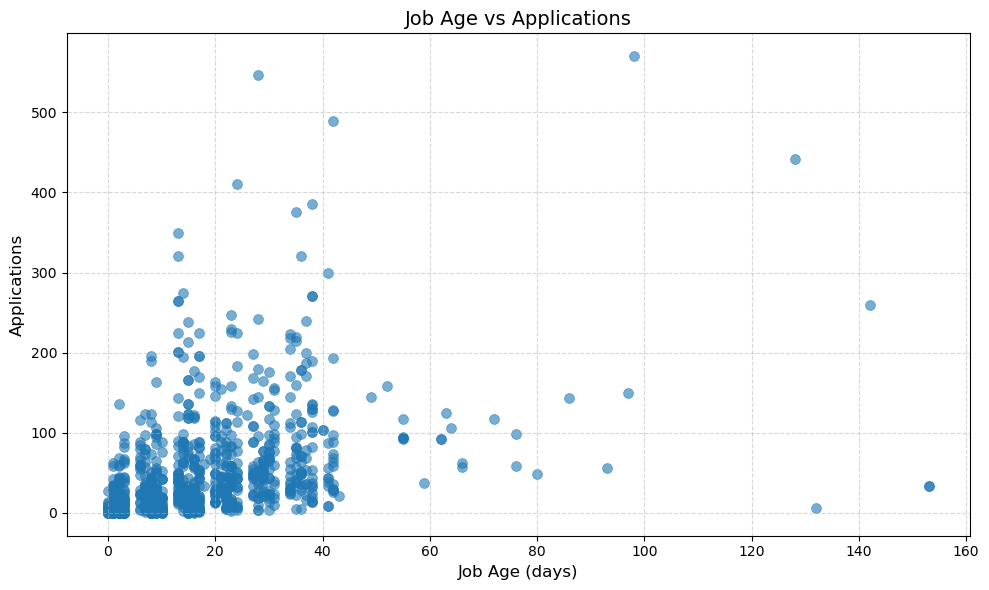

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker

plt.figure(figsize=(10, 6))

# Scatter plot with adjusted appearance
sns.scatterplot(
    data=jobs_reed,
    x='jobAgeDays',
    y='applications',
    alpha=0.6,            # Transparency to reduce overlap clutter
    s=50,                 # Marker size
    edgecolor=None
)

# Title and labels
plt.title("Job Age vs Applications", fontsize=14)
plt.xlabel("Job Age (days)", fontsize=12)
plt.ylabel("Applications", fontsize=12)

# Format y-axis (Applications) as plain integers
plt.gca().yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


In [15]:
max_applications = jobs_reed.loc[jobs_reed['applications'].idxmax()]
print("🔥 Job with the MOST applications:")
print(f"{max_applications['jobTitle']} at {max_applications['employerName']}")
print(f"Applications: {max_applications['applications']}")

min_applications = jobs_reed.loc[jobs_reed['applications'].idxmin()]
print("\n❄️ Job with the LEAST applications:")
print(f"{min_applications['jobTitle']} at {min_applications['employerName']}")
print(f"Applications: {min_applications['applications']}")

# jobs_reed[jobs_reed['applications'] == 0]

avg_applications = jobs_reed['applications'].mean()
print(f"\n📊 Average applications per job: {avg_applications:.2f}")


🔥 Job with the MOST applications:
IT Support Analyst at GroupNexus
Applications: 570

❄️ Job with the LEAST applications:
AI Security Consultant at Marshall Wolfe
Applications: 0

📊 Average applications per job: 49.44


In [16]:
total_jobs = len(jobs_reed)
total_applications = jobs_reed['applications'].sum()

jobs_to_applications_ratio =  total_applications/  total_jobs
print(f"🔁 Applications-to-Jobs Ratio: {jobs_to_applications_ratio:.4f} ( application per jobs )")


🔁 Applications-to-Jobs Ratio: 49.4360 ( application per jobs )


In [17]:
older_than_30 = jobs_reed[jobs_reed['jobAgeDays'] > 30]
percent_older_than_30 = (len(older_than_30) / len(jobs_reed)) * 100

print(f"📌 Jobs older than 30 days: {len(older_than_30)}")
print(f"📊 Percentage of total: {percent_older_than_30:.2f}%")

posted_last_7_days = jobs_reed[jobs_reed['jobAgeDays'] <= 7]
percent_posted_last_7 = (len(posted_last_7_days) / len(jobs_reed)) * 100

print(f"📌 Jobs posted in last 7 days: {len(posted_last_7_days)}")
print(f"📊 Percentage of total: {percent_posted_last_7:.2f}%")


📌 Jobs older than 30 days: 156
📊 Percentage of total: 15.97%
📌 Jobs posted in last 7 days: 233
📊 Percentage of total: 23.85%


In [18]:
remote_jobs = jobs_reed[
    jobs_reed['jobTitle'].str.contains("remote", case=False, na=False) |
    jobs_reed['jobDescription'].str.contains("remote", case=False, na=False) |
    jobs_reed['locationName'].str.contains("remote", case=False, na=False)
]

hybrid_jobs = jobs_reed[
    jobs_reed['jobTitle'].str.contains("hybrid", case=False, na=False) |
    jobs_reed['jobDescription'].str.contains("hybrid", case=False, na=False) |
    jobs_reed['locationName'].str.contains("hybrid", case=False, na=False)
]

percent_remote = (len(remote_jobs) / len(jobs_reed)) * 100
percent_hybrid = (len(hybrid_jobs) / len(jobs_reed)) * 100

print(f"🏠 Remote jobs: {len(remote_jobs)} ({percent_remote:.2f}%)")
print(f"🏢 Hybrid jobs: {len(hybrid_jobs)} ({percent_hybrid:.2f}%)")


🏠 Remote jobs: 54 (5.53%)
🏢 Hybrid jobs: 263 (26.92%)


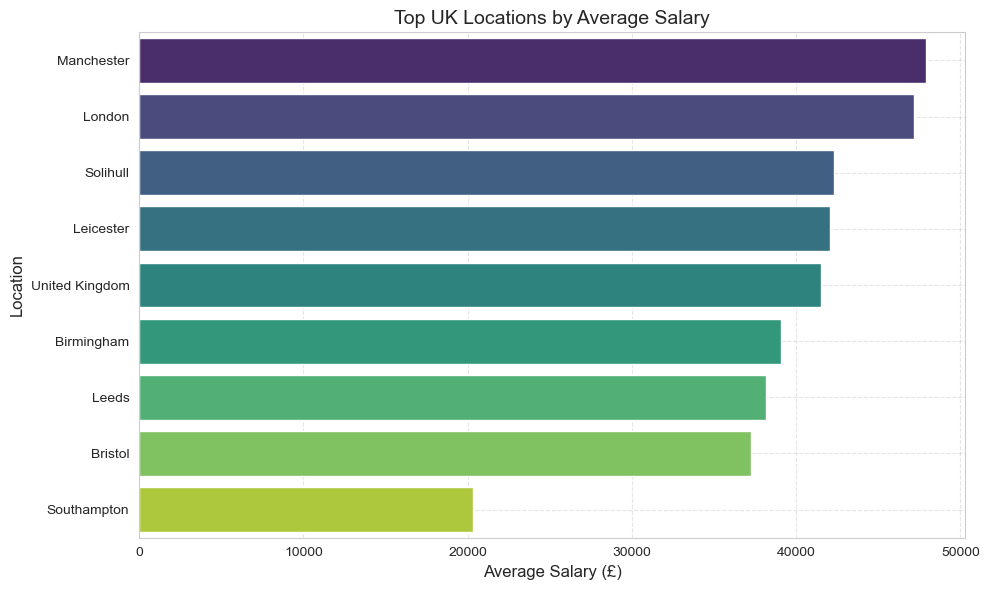

,locationName,job_count,avg_salary
240,Manchester,23,47905.652174
219,London,200,47155.972500
361,Solihull,6,42307.750000
214,Leicester,7,42071.428571
387,United Kingdom,18,41497.083333
36,Birmingham,22,39082.818182
213,Leeds,17,38167.029412
45,Bristol,11,37229.227273
365,Southampton,8,20322.575000


In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate average salary
jobs_reed['salaryAvg'] = (jobs_reed['minimumSalary'] + jobs_reed['maximumSalary']) / 2

# Group by location with count and mean salary
location_salary_stats = (
    jobs_reed.groupby('locationName')
    .agg(job_count=('salaryAvg', 'count'), avg_salary=('salaryAvg', 'mean'))
    .reset_index()
)

# Filter locations with more than 30 job postings
filtered_locations = location_salary_stats[location_salary_stats['job_count'] > 5]

# Get top 15 by average salary
top_locations_salary = filtered_locations.sort_values('avg_salary', ascending=False).head(15)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(
    data=top_locations_salary,
    x='avg_salary',
    y='locationName',
    palette='viridis'
)

plt.title('Top UK Locations by Average Salary', fontsize=14)
plt.xlabel('Average Salary (£)', fontsize=12)
plt.ylabel('Location', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Optional: View top rows
top_locations_salary


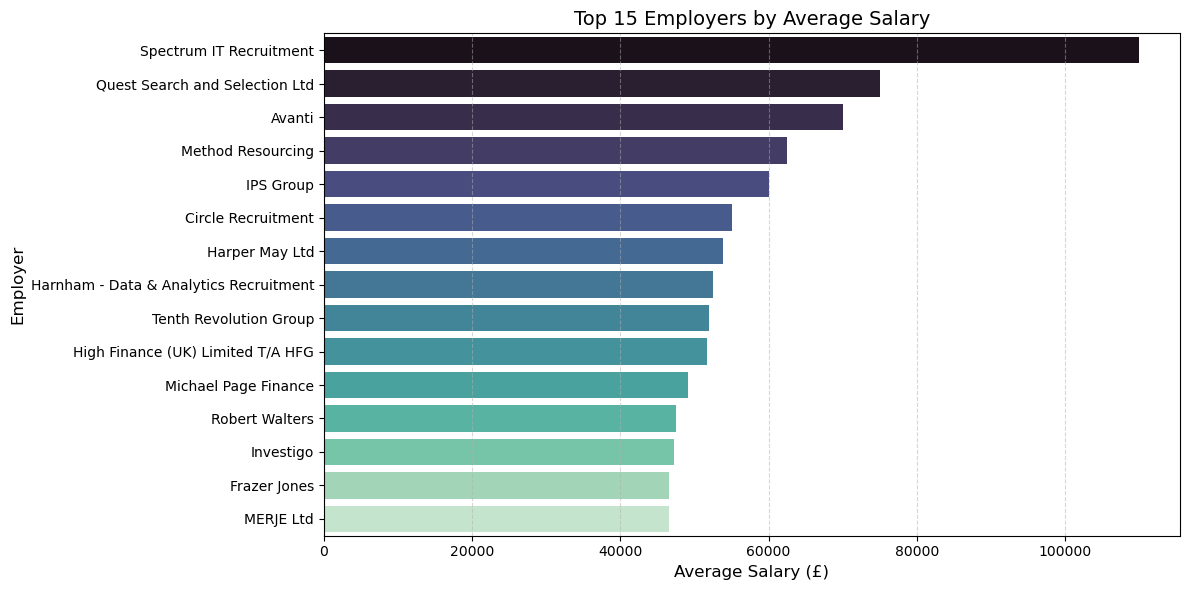

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Ensure salaryAvg is calculated
jobs_reed['salaryAvg'] = (jobs_reed['minimumSalary'] + jobs_reed['maximumSalary']) / 2

# Step 2: Group by employer
employer_salary = (
    jobs_reed.groupby('employerName')
    .agg(jobCount=('jobId', 'count'), avgSalary=('salaryAvg', 'mean'))
    .sort_values('avgSalary', ascending=False)
)

# Step 3: Filter employers with at least 3 listings to avoid noise
employer_salary_filtered = employer_salary[employer_salary['jobCount'] >= 3]

# Step 4: Plot top 15
plt.figure(figsize=(12, 6))
sns.barplot(
    data=employer_salary_filtered.head(15),
    x='avgSalary',
    y=employer_salary_filtered.head(15).index,
    palette='mako'
)

plt.title("Top 15 Employers by Average Salary", fontsize=14)
plt.xlabel("Average Salary (£)", fontsize=12)
plt.ylabel("Employer", fontsize=12)
plt.grid(True, axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


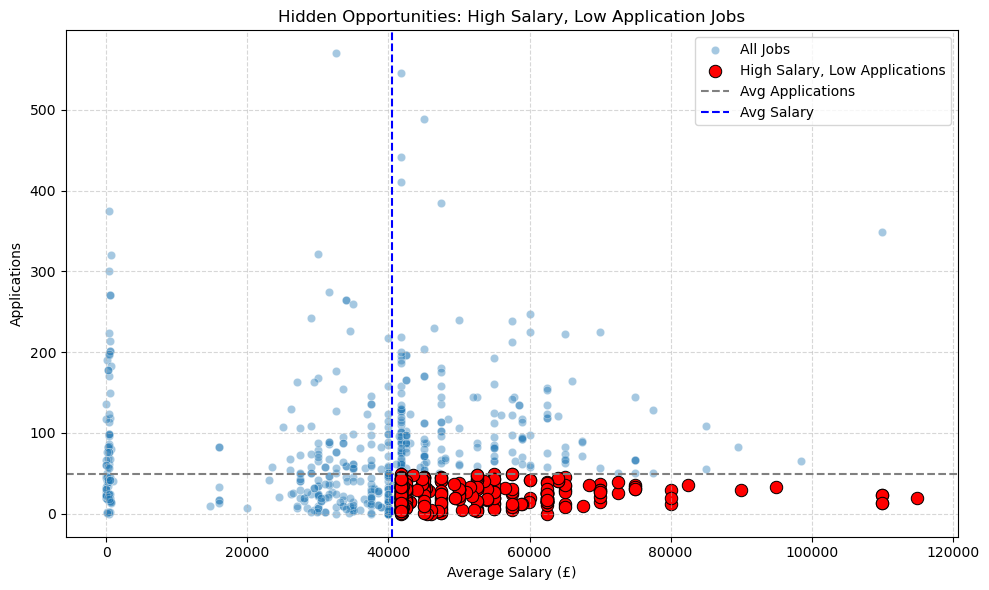

,jobTitle,employerName,locationName,salaryAvg,applications
997,Senior Financial Analyst,Robert Walters,London,115000.0,19
736,Senior Quantitative Analyst,Spectrum IT Recruitment,London,110000.0,13
776,Senior Quantitative Analyst,Spectrum IT Recruitment,London,110000.0,23
822,Senior Quantitative Analyst,Spectrum IT Recruitment,London,110000.0,23
819,Senior Quantitative Analyst,Spectrum IT Recruitment,London,110000.0,13
669,Lead Data Scientist,Harnham - Data & Analytics Recruitment,Manchester,95000.0,33
791,Lead Product Analyst,Harnham - Data & Analytics Recruitment,London,90000.0,29
585,Finance Analyst,Halliday Marx,London,82500.0,36
317,Senior Data Enablement Analyst,Method Resourcing,London,80000.0,12
853,Senior Product Analyst,Harnham - Data & Analytics Recruitment,London,80000.0,29


In [21]:
# Step 1: Ensure salaryAvg is available
jobs_reed['salaryAvg'] = (jobs_reed['minimumSalary'] + jobs_reed['maximumSalary']) / 2

# Step 2: Get overall means
mean_salary = jobs_reed['salaryAvg'].mean()
mean_applications = jobs_reed['applications'].mean()

# Step 3: Filter hidden opportunities
hidden_opportunities = jobs_reed[
    (jobs_reed['salaryAvg'] > mean_salary) &
    (jobs_reed['applications'] < mean_applications)
]

# Step 4: Sort by highest salary
hidden_opportunities_sorted = hidden_opportunities.sort_values(by='salaryAvg', ascending=False)

# Display top 10


import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=jobs_reed,
    x='salaryAvg',
    y='applications',
    alpha=0.4,
    label='All Jobs'
)

# Highlight hidden opportunities
sns.scatterplot(
    data=hidden_opportunities_sorted,
    x='salaryAvg',
    y='applications',
    color='red',
    label='High Salary, Low Applications',
    s=80,
    edgecolor='black'
)

plt.axhline(mean_applications, linestyle='--', color='gray', label='Avg Applications')
plt.axvline(mean_salary, linestyle='--', color='blue', label='Avg Salary')

plt.title('Hidden Opportunities: High Salary, Low Application Jobs')
plt.xlabel('Average Salary (£)')
plt.ylabel('Applications')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

hidden_opportunities_sorted[['jobTitle', 'employerName', 'locationName', 'salaryAvg', 'applications']].head(10)

/home/obsidian/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


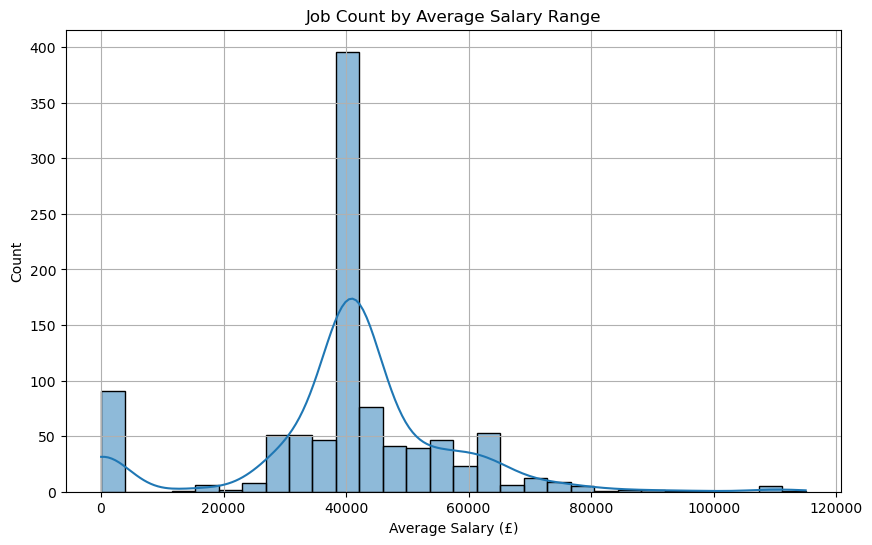

In [22]:
# filtered_jobs = jobs_reed[jobs_reed['salaryAvg'] ]

plt.figure(figsize=(10, 6))
sns.histplot(jobs_reed['salaryAvg'], kde=True, bins=30)
plt.title("Job Count by Average Salary Range")
plt.xlabel('Average Salary (£)')
plt.grid(True)
plt.show()

# Filter out extreme salary outliers (>100k)

In [23]:
# Count how many jobs each company is offering
top_employers = jobs_reed['employerName'].value_counts()

# View the top 10 companies
print(top_employers.head(20))


employerName
ITOL Recruit                              183
Harnham - Data & Analytics Recruitment     87
Reed                                       30
Hays Specialist Recruitment Limited        26
Tenth Revolution Group                     24
Robert Half                                23
Robert Walters                             20
Newto Training                             15
Sanderson                                  12
Michael Page Finance                       12
QA                                         10
Harper May Ltd                              9
Adecco                                      8
Oscar Technology                            7
Mitchell Adam                               7
Gleeson Recruitment Group                   6
The Portfolio Group                         6
Frazer Jones                                6
Marks Sattin                                6
Nxtgen Recruitment                          5
Name: count, dtype: int64


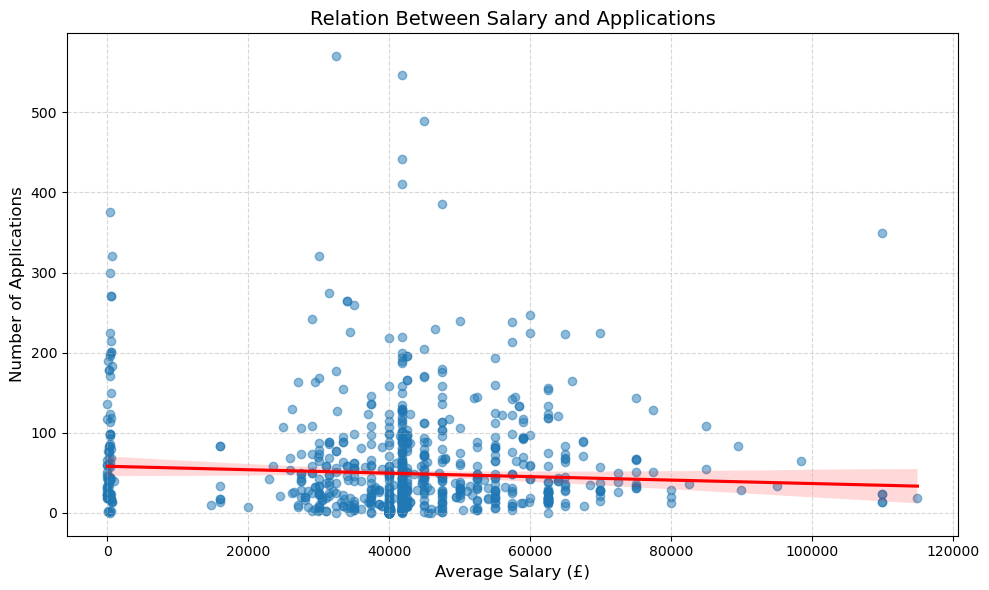

Pearson Correlation Coefficient: -0.058 (p-value: 0.0706)


In [24]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

# Step 1: Ensure salaryAvg is calculated
jobs_reed['salaryAvg'] = (jobs_reed['minimumSalary'] + jobs_reed['maximumSalary']) / 2

# Step 2: Scatterplot with regression line
plt.figure(figsize=(10, 6))
sns.regplot(
    data=jobs_reed,
    x='salaryAvg',
    y='applications',
    scatter_kws={'alpha': 0.5},
    line_kws={'color': 'red'},
)

plt.title("Relation Between Salary and Applications", fontsize=14)
plt.xlabel("Average Salary (£)", fontsize=12)
plt.ylabel("Number of Applications", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Step 3: Pearson correlation coefficient
corr, p_value = pearsonr(jobs_reed['salaryAvg'], jobs_reed['applications'])
print(f"Pearson Correlation Coefficient: {corr:.3f} (p-value: {p_value:.4f})")


In [34]:
correlation_matrix = jobs_reed[['salaryAvg', 'jobAgeDays', 'applications']].corr()
print(correlation_matrix)


              salaryAvg  jobAgeDays  applications
salaryAvg      1.000000    0.033179     -0.057870
jobAgeDays     0.033179    1.000000      0.400249
applications  -0.057870    0.400249      1.000000


In [35]:
correlation_matrix = jobs_reed[['salaryAvg', 'jobAgeDays', 'applications']].corr()
print(correlation_matrix)


              salaryAvg  jobAgeDays  applications
salaryAvg      1.000000    0.033179     -0.057870
jobAgeDays     0.033179    1.000000      0.400249
applications  -0.057870    0.400249      1.000000
